In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, concatenate, LeakyReLU, Reshape,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score
import albumentations as A

# Architecture of the different models

In [ ]:
#dimension of picture and grid size
h=416
g=5

In [ ]:
def build_yolo_lac1(input_shape=(h, h, 3), grid_size=g, num_boxes=1, num_classes=1):
    inputs = Input(shape=input_shape)                                           

    ## LSM reduce size
    lsm1 = Conv2D(16, (2, 2), padding='same')(inputs) # 208*208*16
    lsm1 = LeakyReLU(negative_slope=0.3)(lsm1)

    #LSM1
    lsm11 = MaxPooling2D((2, 2), strides=(2, 2))(lsm1) # 104*104*16
    lsm12 = Conv2D(16, (1, 1), padding='same')(lsm11) # 104*104*16
    lsm12 = LeakyReLU(negative_slope=0.3)(lsm12)

    #LSM2
    lsm21 = Conv2D(8, (1, 1), padding='same')(lsm1) # 208*208*8
    lsm21 = LeakyReLU(negative_slope=0.3)(lsm21)
    lsm22 = Conv2D(8, (3, 3),strides=(2,2), padding='same')(lsm21) # 104*104*8
    lsm22 = LeakyReLU(negative_slope=0.3)(lsm22)
    lsm23 = Conv2D(16, (1, 1), padding='same')(lsm22) # 104*104*16
    lsm23 = LeakyReLU(negative_slope=0.3)(lsm23)

    #fusion LSM1-LSM2
    lsm_outputs = concatenate([lsm12, lsm23]) # 104*104*32


    ## EFM Feature extraction
    def CSPBlock(input):
        csp1 = Conv2D(32, (3, 3),strides=(2,2), padding='same')(input) # 52*52*32
        csp1 = LeakyReLU(negative_slope=0.3)(csp1)
        
        csp21 = Conv2D(32, (3, 3), padding='same')(csp1) 
        csp21 = LeakyReLU(negative_slope=0.3)(csp21)
        csp211 = Conv2D(32, (3, 3), padding='same')(csp21)
        csp211 = LeakyReLU(negative_slope=0.3)(csp211)

        csp22 = concatenate([csp1, csp21])  # Fusion of two branches #52*52*64
        csp23 = Conv2D(32, (1, 1), padding='same')(csp22)
        csp23 = LeakyReLU(negative_slope=0.3)(csp23)

        csp2 = concatenate([csp1, csp23])  # final Fusion
        return csp2
    
    def AttentionModule(input):
        am11 = GlobalAveragePooling2D(strides=(2, 2))(input)
        am12 = MaxPooling2D(strides=(2, 2))(input) 

        am2 = concatenate([am11, am12]) # 1*1*256
        
        am32 = Conv2D(64,(1,1), padding='same')(am2)
        am32 = LeakyReLU(negative_slope=0.3)(am32)

        am31 = Conv2D(128,(3,3), padding='same')(am2)
        am31 = LeakyReLU(negative_slope=0.3)(am31)
        am32 = Conv2D(64,(1,1), padding='same')(am31)
        am32 = LeakyReLU(negative_slope=0.3)(am32)
        am33 = Conv2D(64,(3,3), padding='same')(am32) # 1*1*64
        am33 = LeakyReLU(negative_slope=0.3)(am33)

        am4 = concatenate([am31, am33]) # 1*1*128

        am5 = Conv2D(16,(1,1), padding='same')(am4)
        am5 = LeakyReLU(negative_slope=0.3)(am5)

        am6 = Conv2D(256,(1,1), padding='same', activation='sigmoid')(am5) # 1*1*256

        am7 = tf.multiply(input, am6) # 26*26*256

        return am7
    
    def CSP_SPPBlock(input):
        def SPP_NET(input):
            spp11 = MaxPooling2D(pool_size=(5, 5), strides=(1, 1), padding='same')(input) # 26*26*64
            spp12 = MaxPooling2D(pool_size=(9, 9), strides=(1, 1), padding='same')(input) # 26*26*64
            spp13 = MaxPooling2D(pool_size=(13, 13), strides=(1, 1), padding='same')(input) # 26*26*64

            return concatenate([input, spp11, spp12, spp13]) # 26*26*128
        
        spp1 = Conv2D(256, (3, 3), padding='same')(input)
        spp1 = LeakyReLU(negative_slope=0.3)(spp1)

        spp21 = Conv2D(128, (3, 3), padding='same')(spp1) # 26*26*128
        spp21 = LeakyReLU(negative_slope=0.3)(spp21)
        spp22 = Conv2D(64, (3, 3), padding='same')(spp21) # 26*26*64
        spp22 = LeakyReLU(negative_slope=0.3)(spp22)

        spp31 = Conv2D(64, (3, 3), padding='same')(spp22) # 26*26*64
        spp31 = LeakyReLU(negative_slope=0.3)(spp31)
        spp32 = Conv2D(64, (1, 1), padding='same')(spp31) # 26*26*64
        spp32 = LeakyReLU(negative_slope=0.3)(spp32)
        spp33 = SPP_NET(spp32) # 26*26*128
        spp34 = Conv2D(64, (1, 1), padding='same')(spp33) # 26*26*64
        spp34 = LeakyReLU(negative_slope=0.3)(spp34)

        spp4 = concatenate([spp34,spp22]) #26*26*128
        spp5 = Conv2D(256, (3, 3), padding='same')(spp4) # 26*26*256
        spp5 = LeakyReLU(negative_slope=0.3)(spp5)

        spp6 = concatenate([spp5,spp1]) # 26*26*512
        spp7 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(spp6) # 13*13*256
        spp8 = Conv2D(256, (1, 1), padding='same')(spp7) # 13*13*256
        spp8 = LeakyReLU(negative_slope=0.3)(spp8)

        return spp8
    
    efm1 = CSPBlock(lsm_outputs) # 52*52*32
    #efm2 = CSPBlock(efm1) # 26*26*256
    #efm3 = AttentionModule(efm2) # 26*26*256
    #efm4 = CSP_SPPBlock(efm3) # 13*13*512

    efm_outputs = efm1 # 52*52*31

    # to tackle absence of CSP_block
    preadm = Conv2D(32, (3, 3),strides=(2,2), padding='same')(efm_outputs) # 26*26*32
    preadm = LeakyReLU(negative_slope=0.3)(preadm)
 
    # ADM module for detection 
    def ADM(input):
        adm1 = Conv2D(64, (1, 1), padding='same')(input) # 26*26*64
        adm1 = LeakyReLU(negative_slope=0.3)(adm1)

        adm21 = Conv2D(32, (1, 1), padding='same')(adm1) # 26*26*32
        adm21 = LeakyReLU(negative_slope=0.3)(adm21)
        adm22 = Conv2D(16, (3, 3), padding='same')(adm21) # 26*26*16
        adm22 = LeakyReLU(negative_slope=0.3)(adm22)
        adm23 = Conv2D(16, (3, 3), padding='same')(adm22) # 26*26*16
        adm23 = LeakyReLU(negative_slope=0.3)(adm23)

        adm31 = Conv2D(16, (1, 1), padding='same')(adm1) # 26*26*32
        adm31 = LeakyReLU(negative_slope=0.3)(adm31)
        adm32 = Conv2D(32, (3, 3), padding='same')(adm31) # 26*26*32
        adm32 = LeakyReLU(negative_slope=0.3)(adm32)

        adm4= concatenate([adm23, adm32, adm1]) # 26*26*224
        adm5= Conv2D(64, (1, 1), padding='same')(adm4) # 26*26*128  # expensive in term of parameters
        adm5 = LeakyReLU(negative_slope=0.3)(adm5)

        return adm5
    
    #adm_output = ADM(efm_outputs) 
    adm_output = ADM(preadm) # 26*26*128

    # Output 
    out1 = Conv2D(8, (3, 3),strides=(1,1), padding='same')(adm_output) # 52*52*32
    out1 = LeakyReLU(negative_slope=0.3)(out1)
    out12 = Conv2D(5, (3, 3),strides=(1, 1), padding='same')(out1) # 52*52*16
    out12 = LeakyReLU(negative_slope=0.3)(out12)
    out14 = Conv2D(5, (3, 3),strides=(2, 2), padding='same')(out12) # 26*26*5
    out14 = LeakyReLU(negative_slope=0.3)(out14)
    out15 = Conv2D(5, (3, 3),strides=(2, 2), padding='same')(out14) # 26*26*5
    out15 = LeakyReLU(negative_slope=0.3)(out15)
    out16 = Conv2D(5, (3, 3),strides=(3, 3), padding='same',activation='sigmoid')(out15) # 5*5*5
    outputs = Reshape((grid_size, grid_size, 5))(out16)  # Reshape desired into spatial form
  

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [3]:
def build_yolo_la1(input_shape=(h, h, 3), grid_size=5*5, num_boxes=1, num_classes=1):
    inputs = Input(shape=input_shape)                                           

    ## LSM reduce size
    lsm1 = Conv2D(16, (2, 2), padding='same')(inputs) # 208*208*16
    lsm1 = LeakyReLU(negative_slope=0.1)(lsm1)

    #LSM1
    lsm11 = MaxPooling2D((2, 2), strides=(2, 2))(lsm1) # 104*104*16
    lsm12 = Conv2D(16, (1, 1), padding='same')(lsm11) # 104*104*16
    lsm12 = LeakyReLU(negative_slope=0.1)(lsm12)

    #LSM2
    lsm21 = Conv2D(8, (1, 1), padding='same')(lsm1) # 208*208*8
    lsm21 = LeakyReLU(negative_slope=0.1)(lsm21)
    lsm22 = Conv2D(8, (3, 3),strides=(2,2), padding='same')(lsm21) # 104*104*8
    lsm22 = LeakyReLU(negative_slope=0.1)(lsm22)
    lsm23 = Conv2D(16, (1, 1), padding='same')(lsm22) # 104*104*16
    lsm23 = LeakyReLU(negative_slope=0.1)(lsm23)

    #fusion LSM1-LSM2
    lsm_outputs = concatenate([lsm12, lsm23]) # 104*104*32


    ## EFM Feature extraction
    def CSPBlock(input):
        csp1 = Conv2D(32, (3, 3),strides=(2,2), padding='same')(input)
        csp1 = LeakyReLU(negative_slope=0.1)(csp1)
        
        csp21 = Conv2D(32, (3, 3), padding='same')(csp1)
        csp21 = LeakyReLU(negative_slope=0.1)(csp21)
        csp211 = Conv2D(32, (3, 3), padding='same')(csp21)
        csp211 = LeakyReLU(negative_slope=0.1)(csp211)

        csp22 = concatenate([csp1, csp21])  # Fusion des deux branches
        csp23 = Conv2D(32, (1, 1), padding='same')(csp22)
        csp23 = LeakyReLU(negative_slope=0.1)(csp23)

        csp2 = concatenate([csp1, csp23])  # Fusion finale
        return csp2
    
    def AttentionModule(input):
        am11 = GlobalAveragePooling2D(strides=(2, 2))(input)
        am12 = MaxPooling2D(strides=(2, 2))(input) 

        am2 = concatenate([am11, am12]) # 1*1*256
        
        am32 = Conv2D(64,(1,1), padding='same')(am2)
        am32 = LeakyReLU(negative_slope=0.1)(am32)

        am31 = Conv2D(128,(3,3), padding='same')(am2)
        am31 = LeakyReLU(negative_slope=0.1)(am31)
        am32 = Conv2D(64,(1,1), padding='same')(am31)
        am32 = LeakyReLU(negative_slope=0.1)(am32)
        am33 = Conv2D(64,(3,3), padding='same')(am32) # 1*1*64
        am33 = LeakyReLU(negative_slope=0.1)(am33)

        am4 = concatenate([am31, am33]) # 1*1*128

        am5 = Conv2D(16,(1,1), padding='same')(am4)
        am5 = LeakyReLU(negative_slope=0.1)(am5)

        am6 = Conv2D(256,(1,1), padding='same', activation='sigmoid')(am5) # 1*1*256

        am7 = tf.multiply(input, am6) # 26*26*256

        return am7
    
    def CSP_SPPBlock(input):
        def SPP_NET(input):
            spp11 = MaxPooling2D(pool_size=(5, 5), strides=(1, 1), padding='same')(input) # 26*26*64
            spp12 = MaxPooling2D(pool_size=(9, 9), strides=(1, 1), padding='same')(input) # 26*26*64
            spp13 = MaxPooling2D(pool_size=(13, 13), strides=(1, 1), padding='same')(input) # 26*26*64

            return concatenate([input, spp11, spp12, spp13]) # 26*26*128
        
        spp1 = Conv2D(256, (3, 3), padding='same')(input)
        spp1 = LeakyReLU(negative_slope=0.1)(spp1)

        spp21 = Conv2D(128, (3, 3), padding='same')(spp1) # 26*26*128
        spp21 = LeakyReLU(negative_slope=0.1)(spp21)
        spp22 = Conv2D(64, (3, 3), padding='same')(spp21) # 26*26*64
        spp22 = LeakyReLU(negative_slope=0.1)(spp22)

        spp31 = Conv2D(64, (3, 3), padding='same')(spp22) # 26*26*64
        spp31 = LeakyReLU(negative_slope=0.1)(spp31)
        spp32 = Conv2D(64, (1, 1), padding='same')(spp31) # 26*26*64
        spp32 = LeakyReLU(negative_slope=0.1)(spp32)
        spp33 = SPP_NET(spp32) # 26*26*128
        spp34 = Conv2D(64, (1, 1), padding='same')(spp33) # 26*26*64
        spp34 = LeakyReLU(negative_slope=0.1)(spp34)

        spp4 = concatenate([spp34,spp22]) #26*26*128
        spp5 = Conv2D(256, (3, 3), padding='same')(spp4) # 26*26*256
        spp5 = LeakyReLU(negative_slope=0.1)(spp5)

        spp6 = concatenate([spp5,spp1]) # 26*26*512
        spp7 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(spp6) # 13*13*256
        spp8 = Conv2D(256, (1, 1), padding='same')(spp7) # 13*13*256
        spp8 = LeakyReLU(negative_slope=0.1)(spp8)

        return spp8
    
    #efm1 = CSPBlock(lsm_outputs) # 52*52*128
    #efm2 = CSPBlock(efm1) # 26*26*256
    #efm3 = AttentionModule(efm2) # 26*26*256
    #efm4 = CSP_SPPBlock(efm3) # 13*13*512

    efm_outputs = lsm_outputs # 208*208*32

    #on ajoute ca pour palier l'absence de CSP_block
    preadm = Conv2D(16, (3, 3),strides=(2,2), padding='same')(efm_outputs) # 104*104*32
    preadm = LeakyReLU(negative_slope=0.1)(preadm)
    preadm1 = Conv2D(16, (3, 3),strides=(2,2), padding='same')(preadm) # 52*52*32
    preadm1 = LeakyReLU(negative_slope=0.1)(preadm1)
    preadm2 = Conv2D(16, (3, 3),strides=(2,2), padding='same')(preadm1) # 26*26*32
    preadm2 = LeakyReLU(negative_slope=0.1)(preadm2)
    # ADM module for detection 
    def ADM(input):
        adm1 = Conv2D(64, (1, 1), padding='same')(input) # 26*26*64
        adm1 = LeakyReLU(negative_slope=0.1)(adm1)

        adm21 = Conv2D(32, (1, 1), padding='same')(adm1) # 26*26*32
        adm21 = LeakyReLU(negative_slope=0.1)(adm21)
        adm22 = Conv2D(16, (3, 3), padding='same')(adm21) # 26*26*16
        adm22 = LeakyReLU(negative_slope=0.1)(adm22)
        adm23 = Conv2D(16, (3, 3), padding='same')(adm22) # 26*26*16
        adm23 = LeakyReLU(negative_slope=0.1)(adm23)

        adm31 = Conv2D(16, (1, 1), padding='same')(adm1) # 26*26*32
        adm31 = LeakyReLU(negative_slope=0.1)(adm31)
        adm32 = Conv2D(32, (3, 3), padding='same')(adm31) # 26*26*32
        adm32 = LeakyReLU(negative_slope=0.1)(adm32)

        adm4= concatenate([adm23, adm32, adm1]) # 26*26*224
        adm5= Conv2D(64, (1, 1), padding='same')(adm4) # 26*26*128  # ON PEU TJOUER SUR CA MAIS CA COUTE CHER EN PARAMETRES
        adm5 = LeakyReLU(negative_slope=0.1)(adm5)

        return adm5
    
    #adm_output = ADM(efm_outputs) 
    adm_output = ADM(preadm2) # 26*26*128

    # Output 
    out1 = Conv2D(8, (3, 3),strides=(1,1), padding='same')(adm_output) # 26*26*32
    out1 = LeakyReLU(negative_slope=0.1)(out1)
    out12 = Conv2D(5, (3, 3),strides=(1, 1), padding='same')(out1) # 26*26*16
    out12 = LeakyReLU(negative_slope=0.1)(out12)
    out14 = Conv2D(5, (3, 3),strides=(2, 2), padding='same')(out1) # 13*13*5
    out14 = LeakyReLU(negative_slope=0.1)(out14)
    out15 = Conv2D(5, (3, 3),strides=(3, 3), padding='same',activation='sigmoid')(out14) # 6*6*5
    outputs = Reshape((grid_size, grid_size, 5))(out15)  # Redonne la forme spatiale
  

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
def build_simple_v01(input_shape=(416, 416, 3), grid_size=5, num_boxes=1, num_classes=1):
    inputs = Input(shape=input_shape)

    # Bloc 1
    x = Conv2D(4, (3, 3), strides=(1, 1), padding='same')(inputs)  # 416x416x8
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 208x208x8

    # Bloc 2
    x = Conv2D(8, (3, 3), strides=(1, 1), padding='same')(x)  # 208x208x16
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 104x104x16

    # Bloc 3
    x = Conv2D(8, (3, 3), strides=(1, 1), padding='same')(x)  # 104x104x16
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 52x52x16

    # Bloc 4 (réduction drastique pour limiter les paramètres)
    x = Conv2D(4, (3, 3), strides=(1, 1), padding='same')(x)  # 52x52x8
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 26x26x8

    # Couche finale pour la grille 5x5
    outputs = Conv2D(5, (1, 1), strides=(6, 6), padding='same', activation='sigmoid')(x)  # 5x5x5

  

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
#compile model
model_40k = build_yolo_lac1(input_shape=(416, 416, 3), grid_size=g, num_boxes=1, num_classes=1)
model_40k.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 416, 416,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 416, 416,  │        208 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_102     │ (None, 416, 416,  │          0 │ conv2d_107[0][0]  │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 416, 416,  │        136 │ leaky_re_lu_102[… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_104     │ (None, 416, 416,  │          0 │ conv2d_109[0][0]  │
│ (LeakyReLU)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 208, 208,  │        584 │ leaky_re_lu_104[… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 208, 208,  │          0 │ leaky_re_lu_102[… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_105     │ (None, 208, 208,  │          0 │ conv2d_110[0][0]  │
│ (LeakyReLU)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 208, 208,  │        272 │ max_pooling2d_5[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 208, 208,  │        144 │ leaky_re_lu_105[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_103     │ (None, 208, 208,  │          0 │ conv2d_108[0][0]  │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_106     │ (None, 208, 208,  │          0 │ conv2d_111[0][0]  │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 208, 208,  │          0 │ leaky_re_lu_103[… │
│ (Concatenate)       │ 32)               │            │ leaky_re_lu_106[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_112 (Conv2D) │ (None, 104, 104,  │      9,248 │ concatenate_20[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_107     │ (None, 104, 104,  │          0 │ conv2d_112[0][0]  │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_113 (Conv2D) │ (None, 104, 104,  │      9,248 │ leaky_re_lu_107[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_108     │ (None, 104, 104,  │          0 │ conv2d_113[0][0]

 Total params: 70,103 (273.84 KB)

 Trainable params: 70,103 (273.84 KB)

 Non-trainable params: 0 (0.00 B)

Conv2D(Dimension of outspace, size of convolution window,stride lenght,
padding ('valid'=no padding/'same'=padding))

# DATA pre-processing :



In [ ]:
# translate yolo annotation to bounding box coordinates
def parse_yolo_annotation(annotation_path):

    with open(annotation_path, 'r') as f:
        lines = f.readlines()
    boxes = []
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.strip().split())
        boxes.append([x_center, y_center, width, height, class_id])
    return boxes

In [ ]:
# conversion tools (depending on methods sometimes a specific format is needed)
def coco_to_xyxy(box):
    """Convertit les coordonnées d'une boîte de format COCO (x_min, y_min, width, height) en format (x_min, y_min, x_max, y_max)"""
    x_min, y_min, width, height = box
    x_max = x_min + width
    y_max = y_min + height
    return [x_min, y_min, x_max, y_max, 1]
def yolo_to_coco_L(box):
    """Convertit les coordonnées d'une boîte de format YOLO (x_center, y_center, width, height,confidence) en format COCO (x_min, y_min, width, height) DENORMALISEES"""
    x_center, y_center, width, height ,_= box
    
    x_min = x_center - width / 2
    y_min = y_center - height / 2
    if x_min < 0:
        x_min = 0
    elif x_min + width > 1:
        width = 1 - x_min
    if y_min < 0:
        y_min = 0
    elif y_min + height > 1:
        height = 1 - y_min
    return [x_min*416, y_min*416, width*416, height*416]
def yolo_to_xyxy(box):
    """les données de bases sont en format YOLO (x_center, y_center, width, height) et on les convertit en format (x_min, y_min, x_max, y_max) pour l'affichage et les calculs de métriques"""

    x_center, y_center, width, height,confidence= box

    x_min = (x_center - width / 2) 
    y_min = (y_center - height / 2)
    x_max = (x_center + width / 2)
    y_max = (y_center + height / 2)

    confidence=1.0
    return [x_min, y_min, x_max, y_max, confidence]
def xyxy_to_coco(box):
    """Convertit les coordonnées d'une boîte de format (x_min, y_min, x_max, y_max,conf) en format COCO (x_min, y_min, width, height)"""
    x_min, y_min, x_max, y_max,_ = box
    width = x_max - x_min
    height = y_max - y_min
    return [x_min, y_min, width, height]

### First approach load entire dataset in the memory (bad idea when dataset become to be large with augmentation)

In [ ]:


full_transform = A.Compose([
     
    #A.RandomCrop(height=h//2, width=h//2,pad_if_needed=True),      # Step 1: Size
    A.HorizontalFlip(p=0.5),                  # Step 2: Basic geometric
    A.CoarseDropout(num_holes_range=(3, 8),  # Step 3: Dropout
                    hole_height_range=(0.05, 0.15),
                    hole_width_range=(0.05, 0.15), p=0.5),
    A.ToGray(p=0.5), #reliance on color feature
     
     A.Affine(rotate=(-180, 180), translate_percent=(0.25, 0.25), scale=(0.8, 1.2), shear=(-10, 10), p=0.5), # step 5 affine rotation,translation
    
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0), #step 6 Domain-Specific and Advanced Augmentations
    A.MotionBlur(p=0.5), # specific aerial
    A.Downscale(p=0.5),  #specific aerial
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5), # specific aerial
    A.PlanckianJitter(p=0.5), # specific aerial
    #A.AtmosphericFog(p=0.5), # specific aerial
    #A.Normalize(), 
], bbox_params=A.BboxParams(format='albumentations', min_visibility=0.2))


def augment_image(image, bboxes,facteur=2):
    """Pour chaque image et box on renvoie une liste de 100 images/box augmentées"""
    augmented_images = []
  
    for _ in range(facteur//2):  #  rotations, flipées donc * images
            
            #augmented = rotate_bright(image=image, bboxes=bboxes)
            augmented = {
                
                'bboxes': bboxes
            }
            augmented_images.append({
           
                'bboxes': augmented['bboxes'],

            })
            if facteur>2:
                
                flip_image = full_transform(image=augmented['image'], bboxes=augmented['bboxes'])
                augmented_images.append({
                  
                'bboxes': flip_image['bboxes'],
            })
        
    return augmented_images

In [ ]:


def load_and_resize_image(img_path, target_size=(416, 416)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Optionnel : conversion RGB
    img = cv2.resize(img, target_size)  # Redimensionnement
    return img

def load_dataset(images_dir, labels_dir,limit=None):


    image_paths = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.jpg') or f.endswith('.png')]
    data = []
    l=0
    for img_path in image_paths:
        if l%100==0:  # Afficher le pourcentage toutes les 100 images
            print(f"Processing...{round(l*100/len(image_paths),2)} %")
   
        l+=1
        # Chemin de l'annotation correspondante
        label_path = os.path.join(labels_dir, os.path.splitext(os.path.basename(img_path))[0] + '.txt')
        if not os.path.exists(label_path):
            continue  # Ignore si pas d'annotation

        # Charger l'imag

        #img=load_and_resize_image(img_path, target_size=(416, 416))
        #normaliser les pixels de l'image en divisant par 255
        #img = img / 255.0
        #img_height, img_width = img.shape[:2]

        # Parse les annotations
        boxes = parse_yolo_annotation(label_path) # n_objet*5
       
        #adapte boxes a coco 
    
        boxes_coco = [yolo_to_coco_L(box) for box in boxes] #n_objet*5
        boxes_coco = [boxes_coco]
        #augmented_data = augment_image(img, boxes_coco)
      

        for aug in boxes_coco:
            boxes=aug
            
            converted_boxes = [coco_to_xyxy(box) for box in boxes]
           
        # transformer les converted_boxes au format 3*3*5 de la sortie du modèle
            converted_boxes = np.array(converted_boxes)
   
            y_box = np.zeros((g,g, 5))

            for box in converted_boxes:
                x_min,y_min, x_max, y_max, confidence = box
                x_min, y_min, x_max, y_max = x_min / 416, y_min /416, x_max / 416, y_max /416
                grid_x = int((x_min+x_max)/2 * g)
                grid_y = int((y_min+y_max)/2 * g)

                y_box[grid_y, grid_x] = [x_min, y_min, x_max, y_max, confidence]

      
            data.append({
               
                'boxes': np.array(y_box),
                
            })
        np.save(f"C:\\Users\\Administrateur\\Documents\\courss\\sem1\\nafml\\project_naml\\drone_dataset_yolo\\toy_dataset\\labels\\{os.path.splitext(os.path.basename(img_path))[0]}.npy", y_box)
    return data



In [ ]:
#1359pictures dans le dataset 

images_dir = "C:/Users/Administrateur/Documents/courss/sem1/nafml/project_naml/drone_dataset_yolo/toy_dataset/images"
labels_dir = "C:/Users/Administrateur/Documents/courss/sem1/nafml/project_naml/drone_dataset_yolo/toy_dataset/labels"
dataset = load_dataset(images_dir, labels_dir) # dt = nombre de drones total, dr = nombre de drones reperables via la grid

Processing...0.0 %
Processing...0.51 %
Processing...1.03 %
Processing...1.54 %
Processing...2.05 %
Processing...2.56 %
Processing...3.08 %
Processing...3.59 %
Processing...4.1 %
Processing...4.61 %
Processing...5.13 %
Processing...5.64 %
Processing...6.15 %
Processing...6.66 %
Processing...7.18 %
Processing...7.69 %
Processing...8.2 %
Processing...8.71 %
Processing...9.23 %
Processing...9.74 %
Processing...10.25 %
Processing...10.77 %
Processing...11.28 %
Processing...11.79 %
Processing...12.3 %
Processing...12.82 %
Processing...13.33 %
Processing...13.84 %
Processing...14.35 %
Processing...14.87 %
Processing...15.38 %
Processing...15.89 %
Processing...16.4 %
Processing...16.92 %
Processing...17.43 %
Processing...17.94 %
Processing...18.45 %
Processing...18.97 %
Processing...19.48 %
Processing...19.99 %
Processing...20.51 %
Processing...21.02 %
Processing...21.53 %
Processing...22.04 %
Processing...22.56 %
Processing...23.07 %
Processing...23.58 %
Processing...24.09 %
Processing...24.6

In [20]:
seed= 42
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=seed) # 80% entrainement
train_dataset, val_dataset = train_test_split(train_dataset, test_size=0.25, random_state=seed) # 20% validation, 60% entrainement

In [21]:
X_train = np.array([item['image'] for item in train_dataset])
y_train = np.array([item['boxes'] for item in train_dataset])

X_val = np.array([item['image'] for item in val_dataset])
y_val = np.array([item['boxes'] for item in val_dataset])

X_test = np.array([item['image'] for item in test_dataset])
y_test = np.array([item['boxes'] for item in test_dataset])

### Better approach load by batch using tensorflows methods

In [7]:
batch_size = 64
img_height = h
img_width = h

In [ ]:
image_dir = "C:\\Users\\Administrateur\\Documents\\courss\\sem1\\nafml\\project_naml\\drone_dataset_yolo\\toy_dataset\\images"
label_dir = "C:\\Users\\Administrateur\\Documents\\courss\\sem1\\nafml\\project_naml\\drone_dataset_yolo\\toy_dataset\\labels"

image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)])
label_paths = sorted([os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".npy")])

dataset = tf.data.Dataset.from_tensor_slices((image_paths, label_paths))

def load_label_np(label_path):
    label_path = label_path.numpy().decode("utf-8")
    label_np = np.load(label_path)  
    return label_np.astype(np.float32)

def load_image_and_label(image_path, label_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (h, h))
    image = image / 255.0
    label = tf.py_function(
        func=load_label_np,
        inp=[label_path],
        Tout=tf.float32
    )
    label.set_shape((g, g, 5))

    return image, label

dataset = dataset.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=1000)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

total_size = len(image_paths)

train_size = int(0.6 * total_size)
val_size   = int(0.2 * total_size)
test_size  = int(0.2 * total_size)

train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)

val_ds = remaining.take(val_size)
remaining_test = remaining.skip(val_size)
test_ds = remaining_test.take(test_size)

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

#### before loading dataset it can be augmented throught this

In [ ]:
def set_augmentation(X1,y1,limit=-1):
    i=0
    X1_augmented = []
    y1_augmented = []
    for img,boxes in zip(X1,y1):

        y1 = []
        
        for box_i in boxes:
            for box in box_i:
                if box[-1] == 1: 
                    y1.append(box)

       
        img = img.astype('float32')
        transformed = full_transform(image=img, bboxes=y1)
        transformed_boxes = transformed['bboxes']
        
        y_box = np.zeros((g,g, 5))
        
        for box in transformed_boxes:
                
                grid_x = int((box[0]+box[2])/2 * g)
                grid_y = int((box[1]+box[3])/2 * g)

                y_box[grid_y, grid_x] = [box[0], box[1], box[2], box[3], 1]
        
        

        X1_augmented.append(transformed['image'])
        y1_augmented.append(y_box)
    return np.array(X1_augmented), np.array(y1_augmented)

full_transform = A.Compose([
     
    #A.RandomCrop(height=h//2, width=h//2,pad_if_needed=True),      # Step 1: Size
    A.HorizontalFlip(p=0.5),                  # Step 2: Basic geometric
    A.CoarseDropout(num_holes_range=(3, 8),  # Step 3: Dropout
                    hole_height_range=(0.05, 0.15),
                    hole_width_range=(0.05, 0.15), p=0.5),
    A.ToGray(p=0.5), #reliance on color feature
     
     A.Affine(rotate=(-180, 180), translate_percent=(0.25, 0.25), scale=(0.8, 1.2), shear=(-10, 10), p=0.5), # step 5 affine rotation,translation
    
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0), #step 6 Domain-Specific and Advanced Augmentations
    A.MotionBlur(p=0.5), # specific aerial
    A.Downscale(p=0.5),  #specific aerial
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5), # specific aerial
    A.PlanckianJitter(p=0.5), # specific aerial
    #A.AtmosphericFog(p=0.5), # specific aerial
    #A.Normalize(), 
], bbox_params=A.BboxParams(format='albumentations', min_visibility=0.2))

# Training

## Loss

In [ ]:
from matplotlib.pylab import beta


def yolo_loss( lambda_noobj=1.5):

    def loss(y_true, y_pred):

        # coordinates
        pred_xywh = y_pred[..., 0:4]
        true_xywh = y_true[..., 0:4]
        # confidence
        pred_conf = y_pred[..., 4]
        true_conf = y_true[..., 4]
        # object or not
        obj_mask = true_conf
        noobj_mask = 1 - obj_mask

        # loss coordinates
        def CIoU(box1, box2):
            # box format: [x_min, y_min, x_max, y_max]
            x_min1, y_min1, x_max1, y_max1,_ = box1 #true box
            x_min2, y_min2, x_max2, y_max2,_ = box2 #predicted box

            # Calculate intersection
            inter_x_min = max(x_min1, x_min2)
            inter_y_min = max(y_min1, y_min2)
            inter_x_max = min(x_max1, x_max2)
            inter_y_max = min(y_max1, y_max2)

            inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)

            # Calculate union
            area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
            area2 = (x_max2 - x_min2) * (y_max2 - y_min2)
            union_area = area1 + area2 - inter_area

            if union_area == 0:
                iou = 0.0 
            else :
                iou = inter_area / union_area

            distance = ((x_min1 + x_max1)/2 - (x_min2 + x_max2)/2)**2 + ((y_min1 + y_max1)/2 - (y_min2 + y_max2)/2)**2
            diagonal_length = ((max(x_max1, x_max2) - min(x_min1, x_min2))**2 + (max(y_max1, y_max2) - min(y_min1, y_min2))**2)
    
            if diagonal_length == 0:
                distance_loss = 0.0 
            else:
                distance_loss = (distance / diagonal_length)

            beta = 4/np.pi**2 * (np.arctan((x_max1 - x_min1) / (y_max1 - y_min1)) - np.arctan((x_max2 - x_min2) / (y_max2 - y_min2)))**2
            alpha = beta / (1 - iou + beta)
            aspect_loss = alpha*beta

            ciou_loss = 1 - iou + distance_loss + aspect_loss

            return ciou_loss
        
        coord_loss =  CIoU(true_xywh - pred_xywh)
        

        # Loss confidence for objets 
        
        conf_obj_loss = tf.reduce_mean(
            tf.reshape(obj_mask, (-1, 1)) * tf.keras.losses.binary_crossentropy(tf.reshape(true_conf, (-1, 1)), tf.reshape(pred_conf, (-1, 1)), from_logits=False)
        )

        # Loss confidence for non-objets 
        conf_noobj_loss = lambda_noobj * tf.reduce_mean(
            tf.reshape(noobj_mask, (-1, 1)) * tf.keras.losses.binary_crossentropy(tf.reshape(true_conf, (-1, 1)), tf.reshape(pred_conf, (-1, 1)), from_logits=False)
        )

        return coord_loss + conf_obj_loss + conf_noobj_loss

    return loss

## training with loss

In [ ]:
# recompile model when we restart the training
model_70k = build_yolo_lac1(input_shape=(416, 416, 3), grid_size=g, num_boxes=1, num_classes=1)
model_70k.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 416, 416,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 416, 416,  │        208 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 416, 416,  │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 416, 416,  │        136 │ leaky_re_lu[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 416, 416,  │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 208, 208,  │        584 │ leaky_re_lu_2[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 208, 208,  │          0 │ leaky_re_lu[0][0] │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 208, 208,  │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 208, 208,  │        272 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 208, 208,  │        144 │ leaky_re_lu_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 208, 208,  │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 208, 208,  │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 208, 208,  │          0 │ leaky_re_lu_1[0]… │
│ (Concatenate)       │ 32)               │            │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 104, 104,  │      9,248 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 104, 104,  │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 104, 104,  │      9,248 │ leaky_re_lu_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 104, 104,  │          0 │ conv2d_6[0][0]  

 Total params: 70,103 (273.84 KB)

 Trainable params: 70,103 (273.84 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_70k.compile(optimizer='adam', loss=yolo_loss())

### training

In [12]:
history = model_70k.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    verbose=1
    )

Epoch 1/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3630s 15s/step - loss: 0.2889 - val_loss: 0.2170
Epoch 2/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 4572s 19s/step - loss: 0.2160 - val_loss: 0.2159
Epoch 3/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3828s 16s/step - loss: 0.2012 - val_loss: 0.1945
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 4087s 17s/step - loss: 0.1915 - val_loss: 0.1658
Epoch 5/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3561s 14s/step - loss: 0.1720 - val_loss: 0.1395
Epoch 6/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3446s 14s/step - loss: 0.1633 - val_loss: 0.1341
Epoch 7/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3573s 15s/step - loss: 0.1603 - val_loss: 0.1242
Epoch 8/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3268s 13s/step - loss: 0.1535 - val_loss: 0.1167
Epoch 9/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 4210s 17s/step - loss: 0.1494 - val_loss: 0.1142
Epoch 10/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3189s 13s/step - loss: 0.1476 - val_loss: 0.1100
Epoch 11/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3330s 14s/step - loss: 0.1421 - val_loss: 0.1059
Epoch 12/50
244/244

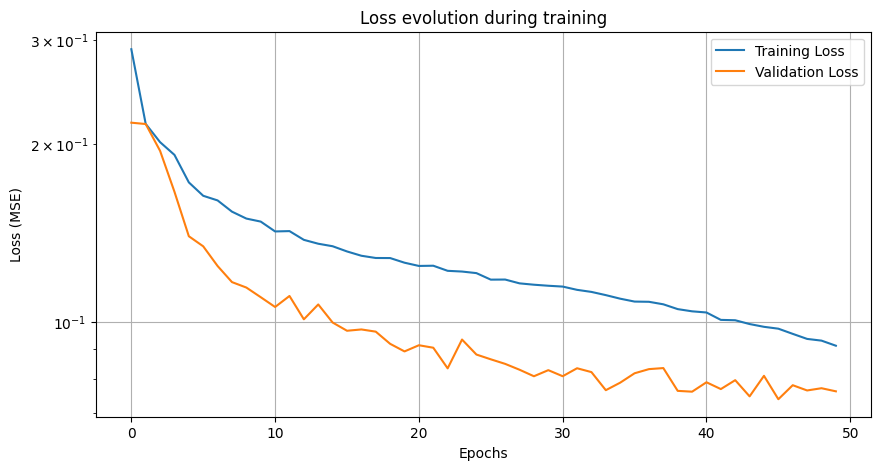

In [ ]:
# loss evolution during training
plt.figure(figsize=(10, 5))
plt.semilogy(history.history['loss'], label='Training Loss')
plt.semilogy(history.history['val_loss'], label='Validation Loss')
plt.title('Loss evolution during training')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()

## Validation of threshold by valdiation set 1

$F1=2×\frac{PrecisionRappel}{Precision+Rappel}$​

Precision : positive prediction quality
Rappel : ability to detect positive

In [ ]:
y_pred_val= model_70k.predict(val_ds)
y_pred_val_1d = y_pred_val[:,:,:,4].reshape(-1)
all_labels= []
for img, lbl in train_ds:
    
    all_labels.append(lbl.numpy())
y_val_1d = np.concatenate([lbl[:,:,:,-1].reshape(-1) for lbl in all_labels])

244/244 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step


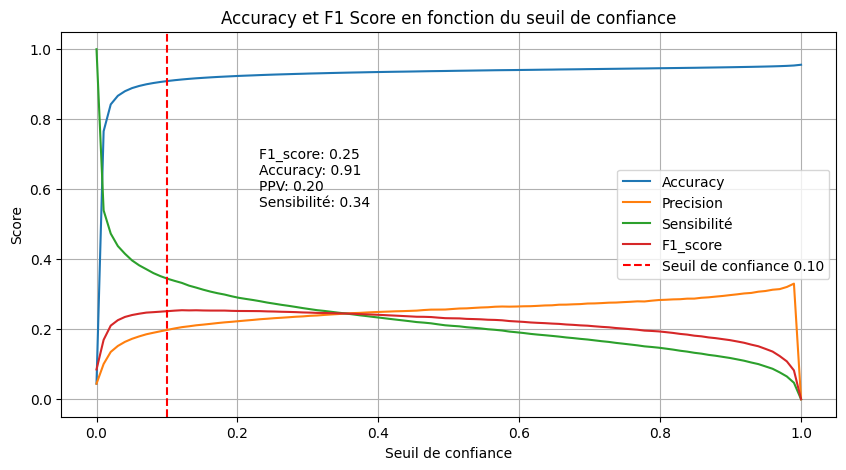

In [ ]:
# we inspect metrics evolution depending on threshold

tresholds = np.linspace(0.0, 1, num=100)
accuracies = np.zeros(100)
f1_scores = np.zeros(100)
sensitivity = np.zeros(100)
ppv = np.zeros(100)
i=0
for th in tresholds:
    
    
  

    y_val_treshold = (y_pred_val_1d > th)

    sensitivity[i] = np.sum((y_val_1d == 1) & (y_val_treshold == 1)) / np.sum(y_val_1d == 1)
    if np.sum(y_val_treshold) == 0:
        ppv[i] = 0
    else:
        ppv[i] = np.sum((y_val_1d == 1) & (y_val_treshold == 1)) / np.sum(y_val_treshold == 1)
    accuracy = accuracy_score(y_val_1d, y_val_treshold)
    f1 = f1_score(y_val_1d, y_val_treshold)
    accuracies[i]=accuracy
    f1_scores[i]=f1
    i+=1  

    
tresholds = np.linspace(0.0, 1, num=100)
plt.figure(figsize=(10, 5))
plt.plot(tresholds, accuracies, label='Accuracy')
plt.plot(tresholds, ppv, label='Precision')
plt.plot(tresholds, sensitivity, label='Sensibilité')
plt.plot(tresholds, f1_scores,label='F1_score')
i=10
plt.axvline(x=i/100, color='red', linestyle='--', label=f'Seuil de confiance {i/100:.2f}')
plt.annotate(f'F1_score: {f1_scores[i]:.2f}\nAccuracy: {accuracies[i]:.2f}\nPPV: {ppv[i]:.2f}\nSensibilité: {sensitivity[i]:.2f}', xy=(0.4, 0.55), xytext=(0.23, 0.55))
plt.title('Accuracy et F1 Score en fonction du seuil de confiance')
plt.xlabel('Seuil de confiance')
plt.ylabel('Score')
plt.legend()
plt.grid()

plt.show()

On chosit donc 0.22 comme seuil de confiance.

In [ ]:
treshold_671 = 0.22

# Model test with validation set 2

In [ ]:
# we test inference speed

import time
t_total = 0
X_test = val_ds.unbatch().map(lambda x, y: x).take(1) 
for i in range(100):
    t1 = time.time()
    model_70k.predict(X_test)  # Prédire sur une seule image pour mesurer le temps d'inférence
    t2 = time.time()
    t_total += (t2 - t1)
print(f"Inference time : {(t_total/100):.4f} secondes")

ValueError: Input 0 with name 'input_layer_1' of layer 'functional_1' is incompatible with the layer: expected shape=(None, 416, 416, 3), found shape=(416, 416, 3)

## Detection independantly of boxes

The most important for us is to reduce the false negative. We want a high sensititvity. Most of the bounding boxes are empty so the accuracy scores is not really interesting.

In [ ]:
y_pred_test = model_70k.predict(test_ds)
all_labels_t= []
for img, lbl in test_ds:
    
    all_labels_t.append(lbl.numpy())
y_test_1d = np.concatenate([lbl[...,-1].reshape(-1) for lbl in all_labels_t])
y_test = np.concatenate([lbl[:,:,:,:] for lbl in all_labels_t])

In [44]:
sens= np.sum(((y_pred_test[...,4].reshape(-1)>treshold_671) == 1) & (y_test_1d == 1)) / np.sum(y_test_1d == 1)
ppv = np.sum(((y_pred_test[...,4].reshape(-1)>treshold_671) == 1) & (y_test_1d == 1)) / np.sum(y_pred_test[...,4].reshape(-1) > treshold_671)
print(f"The sensitivity of the toy model is {sens*100:.2f}% among the test set drones")
print(f"The positive predictive value of the toy model is {ppv*100:.2f}% among the test set drones")

The sensitivity of the toy model is 58.34% among the test set drones
The positive predictive value of the toy model is 7.33% among the test set drones


## Bounding boxes prediction

We will use the same metric as in the study and a widely spread metric : Complete IoU

In [45]:
def CIoU(box1, box2):
    # box format: [x_min, y_min, x_max, y_max]
    x_min1, y_min1, x_max1, y_max1,_ = box1 #true box
    x_min2, y_min2, x_max2, y_max2,_ = box2 #predicted box

    # Calculate intersection
    inter_x_min = max(x_min1, x_min2)
    inter_y_min = max(y_min1, y_min2)
    inter_x_max = min(x_max1, x_max2)
    inter_y_max = min(y_max1, y_max2)

    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)

    # Calculate union
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)
    union_area = area1 + area2 - inter_area

    if union_area == 0:
        iou = 0.0  # Éviter la division par zéro
    else :
        iou = inter_area / union_area

    distance = ((x_min1 + x_max1)/2 - (x_min2 + x_max2)/2)**2 + ((y_min1 + y_max1)/2 - (y_min2 + y_max2)/2)**2
    diagonal_length = ((max(x_max1, x_max2) - min(x_min1, x_min2))**2 + (max(y_max1, y_max2) - min(y_min1, y_min2))**2)
    
    if diagonal_length == 0:
        distance_loss = 0.0  # Éviter la division par zéro
    else:
        distance_loss = (distance / diagonal_length)

    beta = 4/np.pi**2 * (np.arctan((x_max1 - x_min1) / (y_max1 - y_min1)) - np.arctan((x_max2 - x_min2) / (y_max2 - y_min2)))**2
    alpha = beta / (1 - iou + beta)
    aspect_loss = alpha*beta

    ciou_loss = 1 - iou + distance_loss + aspect_loss

    return ciou_loss

In [46]:

ciou_test = []
ciou_val = []
for i in range(272):
    for j in range(g):
        for k in range(g):
            b_test= y_test[i,j,k]
            b_pred= y_pred_test[i,j,k]
            #b_val= y_val[i,j,k]
            #b_pred_val= y_pred_val[i,j,k]
            if (b_test[4]==1) and (b_pred[4] > treshold_671):
                ciou_test.append(CIoU(b_test, b_pred))
            #if (b_val[4]==1) and (b_pred_val[4] > treshold_671):
            #    ciou_val.append(CIoU(b_val, b_pred_val))
ciou_test = np.array(ciou_test)
#ciou_val = np.array(ciou_val)

In [47]:
#print(f"La Complete IoU moyenne sur le val set est de {np.mean(ciou_val):.4f}, avec une standard deviation de {np.std(ciou_val):.4f}")
print(f"La Complete IoU moyenne sur le test set est de {np.mean(ciou_test):.4f}, avec une standard deviation de {np.std(ciou_test):.4f}")


La Complete IoU moyenne sur le test set est de 1.3313, avec une standard deviation de 0.3195


# Save of the training model

In [15]:
model_70k.save("model_70k_3_50.keras")

In [ ]:
# to load the model
model_charge = tf.keras.models.load_model(r"C:\\Users\\Administrateur\\Documents\\courss\\sem1\\nafml\\project_naml\\models\\model_70k.keras", custom_objects={'loss': yolo_loss()})

# check architecture
model_charge.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 416, 416,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_129 (Conv2D) │ (None, 416, 416,  │        208 │ input_layer_6[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_123     │ (None, 416, 416,  │          0 │ conv2d_129[0][0]  │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_131 (Conv2D) │ (None, 416, 416,  │        136 │ leaky_re_lu_123[… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_125     │ (None, 416, 416,  │          0 │ conv2d_131[0][0]  │
│ (LeakyReLU)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_132 (Conv2D) │ (None, 208, 208,  │        584 │ leaky_re_lu_125[… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 208, 208,  │          0 │ leaky_re_lu_123[… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_126     │ (None, 208, 208,  │          0 │ conv2d_132[0][0]  │
│ (LeakyReLU)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_130 (Conv2D) │ (None, 208, 208,  │        272 │ max_pooling2d_6[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_133 (Conv2D) │ (None, 208, 208,  │        144 │ leaky_re_lu_126[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_124     │ (None, 208, 208,  │          0 │ conv2d_130[0][0]  │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_127     │ (None, 208, 208,  │          0 │ conv2d_133[0][0]  │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 208, 208,  │          0 │ leaky_re_lu_124[… │
│ (Concatenate)       │ 32)               │            │ leaky_re_lu_127[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_134 (Conv2D) │ (None, 104, 104,  │      9,248 │ concatenate_24[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_128     │ (None, 104, 104,  │          0 │ conv2d_134[0][0]  │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_135 (Conv2D) │ (None, 104, 104,  │      9,248 │ leaky_re_lu_128[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_129     │ (None, 104, 104,  │          0 │ conv2d_135[0][0]

 Total params: 210,311 (821.53 KB)

 Trainable params: 70,103 (273.84 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 140,208 (547.69 KB)